In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
#reading dataset
df_real = pd.read_csv('ford.csv')
df_real

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [4]:
#checking row and colums
df_real.shape

(17966, 9)

In [5]:
#checking null values
df_real.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [6]:
#checking duplicates
df_real.duplicated().sum()
df = df_real.drop_duplicates()

<Axes: xlabel='price', ylabel='Count'>

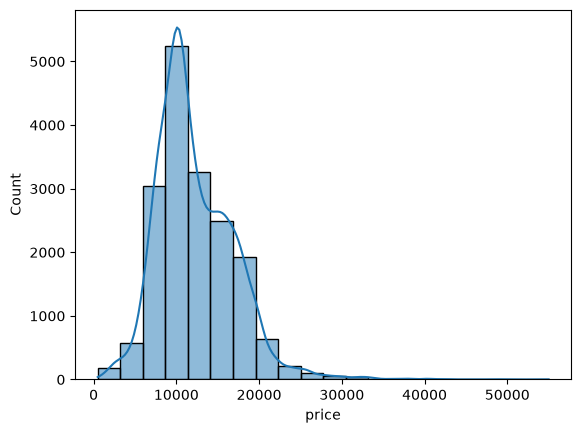

In [7]:
sns.histplot(df['price'],bins=20,kde=True)

<Axes: xlabel='fuelType', ylabel='count'>

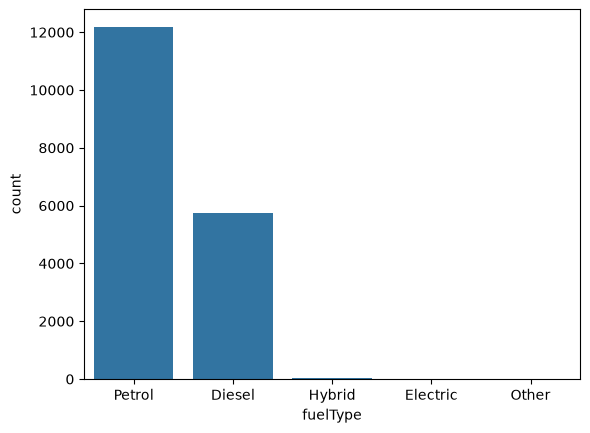

In [8]:
sns.countplot(x=df_real['fuelType'])

<Axes: xlabel='engineSize', ylabel='price'>

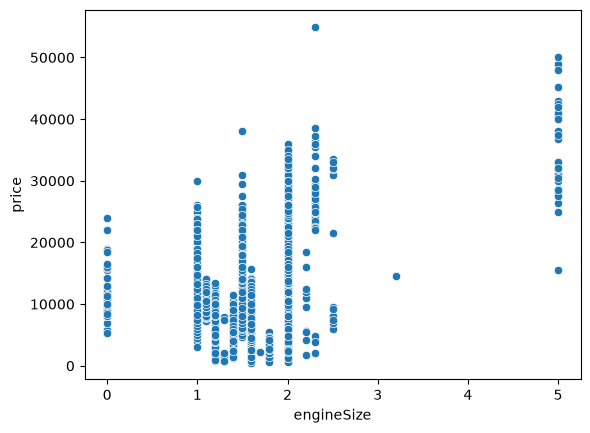

In [9]:
sns.scatterplot(x='engineSize',y='price',data=df)

<Axes: xlabel='mileage', ylabel='price'>

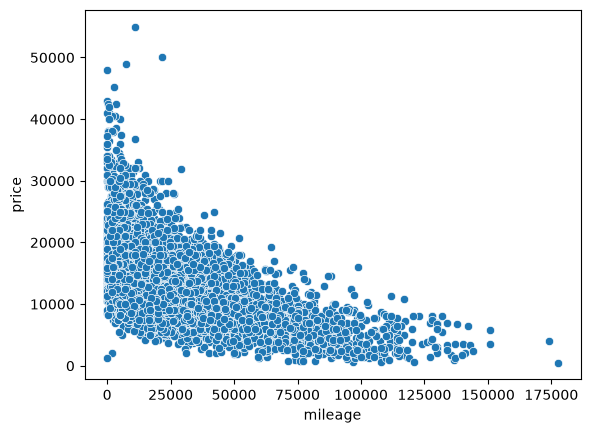

In [10]:
sns.scatterplot(x='mileage',y='price',data=df)

<Axes: xlabel='tax', ylabel='price'>

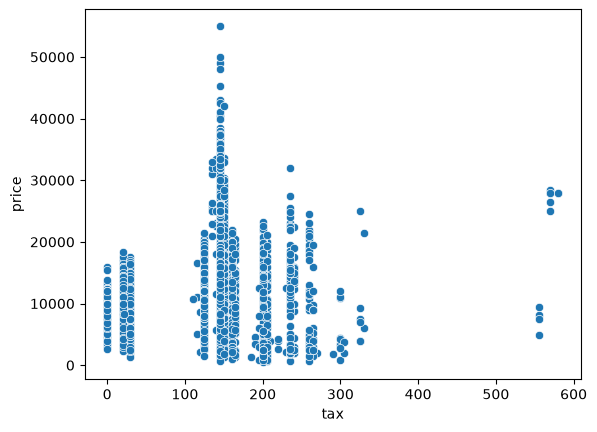

In [11]:
sns.scatterplot(x='tax',y='price',data=df)

<Axes: xlabel='year', ylabel='price'>

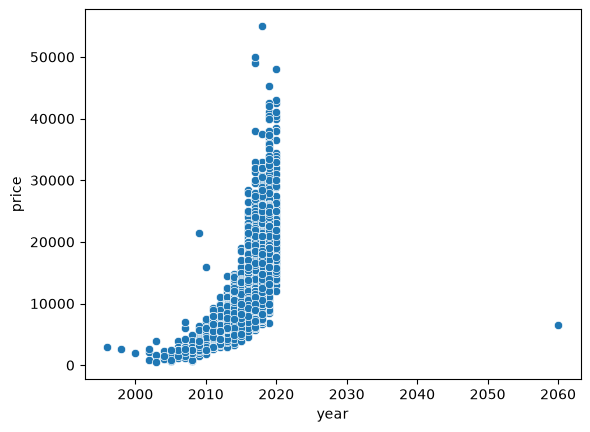

In [12]:
sns.scatterplot(x='year',y='price',data=df)

<Axes: xlabel='mpg', ylabel='price'>

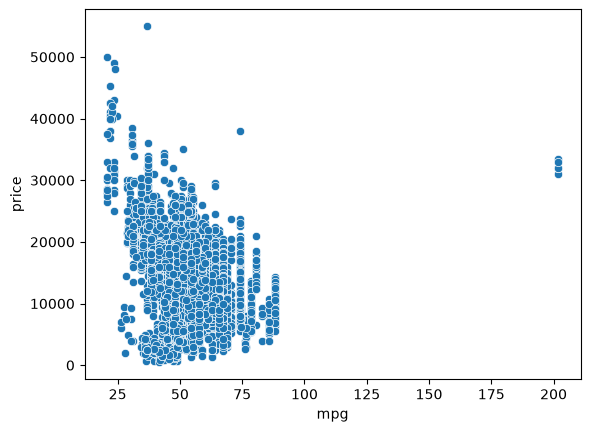

In [13]:
sns.scatterplot(x='mpg',y='price',data=df)

In [14]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='str')

<Axes: xlabel='transmission', ylabel='price'>

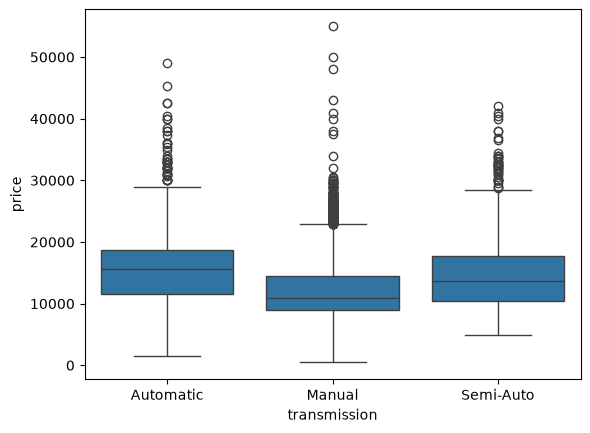

In [15]:
sns.boxplot(x='transmission', y='price', data=df)

<Axes: xlabel='fuelType', ylabel='price'>

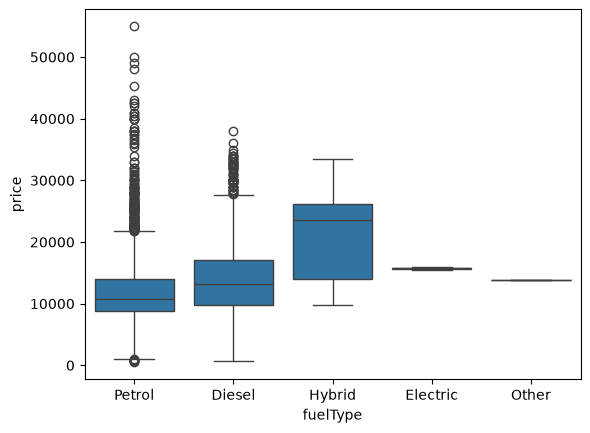

In [16]:
sns.boxplot(x='fuelType', y='price', data=df)

<Axes: xlabel='mileage', ylabel='Count'>

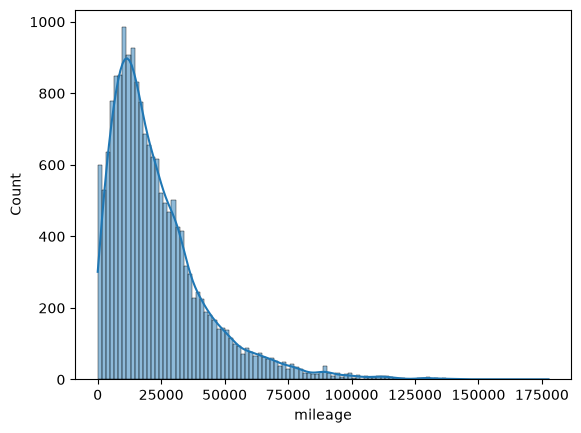

In [17]:
sns.histplot(df['mileage'], kde=True)

<Axes: >

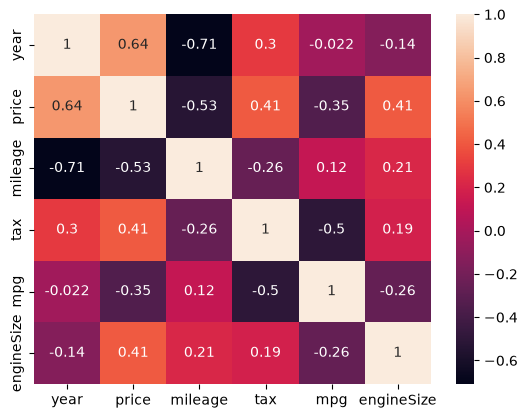

In [18]:
#heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

# Data Preprocessing


In [19]:
#one hot Encoding
df = pd.get_dummies(df,drop_first=True).astype(int)
df

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,14000,9083,150,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,13000,12456,150,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,17500,10460,145,40,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,2019,16500,1482,145,48,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,8999,16700,150,47,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,7499,40700,30,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,9999,7010,20,67,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,8299,5007,145,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [20]:
#standard scaler

In [21]:
df_real.columns
colums = ['engineSize','mpg','tax','mileage','year']

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[colums] =scaler.fit_transform(df[colums])
df


,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,12000,-0.382994,0.591380,-0.042291,-0.446958,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0.554393,14000,-0.736317,0.591380,-0.042291,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.067059,13000,-0.562616,0.591380,-0.042291,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.041726,17500,-0.665405,0.510777,-1.720193,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,1.041726,16500,-1.127749,0.510777,-0.930592,-0.446958,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,8999,-0.344061,0.591380,-1.029292,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.394942,7499,0.891875,-1.343079,-0.042291,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.907608,9999,-0.843071,-1.504284,0.944711,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.554393,8299,-0.946220,0.510777,-0.042291,-0.446958,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


# Feature Selection

In [23]:
# stats
from sklearn.feature_selection import mutual_info_regression
X = df.drop('price',axis=1)
y = df['price']

mi_score = mutual_info_regression(X,y)
mi_series= pd.Series(mi_score,index=X.columns)
mi_series.sort_values(ascending=False)

mpg                             0.513098
year                            0.511648
mileage                         0.279896
tax                             0.278299
engineSize                      0.133151
model_ Fiesta                   0.101065
model_ Kuga                     0.067232
fuelType_Petrol                 0.039705
transmission_Manual             0.035508
model_ Focus                    0.031994
model_ Ka+                      0.029402
model_ Edge                     0.025590
model_ Mustang                  0.020038
model_ EcoSport                 0.019081
model_ KA                       0.018351
transmission_Semi-Auto          0.016057
model_ Galaxy                   0.014824
model_ Puma                     0.014656
model_ Tourneo Custom           0.011143
model_ S-MAX                    0.009970
model_ Fusion                   0.009798
model_ Mondeo                   0.009662
fuelType_Hybrid                 0.005918
model_ Grand Tourneo Connect    0.005468
model_ C-MAX    

In [24]:
df.columns

Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize', 'model_ C-MAX',
       'model_ EcoSport', 'model_ Edge', 'model_ Escort', 'model_ Fiesta',
       'model_ Focus', 'model_ Fusion', 'model_ Galaxy', 'model_ Grand C-MAX',
       'model_ Grand Tourneo Connect', 'model_ KA', 'model_ Ka+',
       'model_ Kuga', 'model_ Mondeo', 'model_ Mustang', 'model_ Puma',
       'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Electric', 'fuelType_Hybrid',
       'fuelType_Other', 'fuelType_Petrol'],
      dtype='str')

In [25]:
col = ['year','mpg','mileage','tax','engineSize']
all= ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model_ C-MAX',
       'model_ EcoSport', 'model_ Edge', 'model_ Escort', 'model_ Fiesta',
       'model_ Focus', 'model_ Fusion', 'model_ Galaxy', 'model_ Grand C-MAX',
       'model_ Grand Tourneo Connect', 'model_ KA', 'model_ Ka+',
       'model_ Kuga', 'model_ Mondeo', 'model_ Mustang', 'model_ Puma',
       'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'transmission_Manual',
       'transmission_Semi-Auto',
        'fuelType_Petrol']

#X=df.drop('price',axis=1)
X = df[all]
y=df['price']

In [26]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Linear Regression


In [27]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](29,)","[ 2149.33,-1207.54, 1.55,..., -751.46, -330.66, -976.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](29,)","['year','mileage','tax',...,'transmission_Manual','transmission_Semi-Auto', 'fuelType_Petrol']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.169e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(29)


In [28]:
y_predict = model.predict(X_test)


In [29]:
#model evaluation
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_predict)
r2


0.8258664879525599

In [30]:
#adjusted r
n = X_test.shape[0]
p= X_test.shape[1]
adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.8244371440948255